In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Setup local paths
train_image_path = r"C:\Users\user\Documents\data\raw\KITTI\training\image_2"
train_label_path = r"C:\Users\user\Documents\data\raw\KITTI\training\label_2"

print(f"Train image path exists: {os.path.exists(train_image_path)}")
print(f"Train label path exists: {os.path.exists(train_label_path)}")

Train image path exists: True
Train label path exists: True


In [4]:
# Function to read KITTI label file
def read_kitti_label_file(label_file_path, image_name):
    objects = []
    
    if not os.path.exists(label_file_path):
        return objects
    
    with open(label_file_path, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 1:
            continue
            
        obj = {
            'id': parts[0],
            'truncated': float(parts[1]) if len(parts) > 1 else 0,
            'occluded': int(parts[2]) if len(parts) > 2 else 0,
            'alpha': float(parts[3]) if len(parts) > 3 else 0,
            'bbox_left': float(parts[4]) if len(parts) > 4 else 0,
            'bbox_top': float(parts[5]) if len(parts) > 5 else 0,
            'bbox_right': float(parts[6]) if len(parts) > 6 else 0,
            'bbox_bottom': float(parts[7]) if len(parts) > 7 else 0,
            'category': parts[0],  # First element is the class
            'image_name': image_name
        }
        objects.append(obj)
    
    return objects

In [5]:
# Read all label files
print("Reading label files...")

all_objects = []
image_files = [f for f in os.listdir(train_image_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

for img_file in image_files:
    base_name = os.path.splitext(img_file)[0]
    label_file = os.path.join(train_label_path, base_name + '.txt')
    
    objects = read_kitti_label_file(label_file, img_file)
    all_objects.extend(objects)

df_labels = pd.DataFrame(all_objects)

print(f"Number of images: {len(image_files)}")
print(f"Number of annotations: {len(df_labels)}")
print(f"Columns: {df_labels.columns.tolist()}")
print("\nSample data:")
print(df_labels.head())

Reading label files...
Number of images: 7481
Number of annotations: 51865
Columns: ['id', 'truncated', 'occluded', 'alpha', 'bbox_left', 'bbox_top', 'bbox_right', 'bbox_bottom', 'category', 'image_name']

Sample data:
           id  truncated  occluded  alpha  bbox_left  bbox_top  bbox_right  \
0  Pedestrian        0.0         0  -0.20     712.40    143.00      810.73   
1       Truck        0.0         0  -1.57     599.41    156.40      629.75   
2         Car        0.0         0   1.85     387.63    181.54      423.81   
3     Cyclist        0.0         3  -1.65     676.60    163.95      688.98   
4    DontCare       -1.0        -1 -10.00     503.89    169.71      590.61   

   bbox_bottom    category  image_name  
0       307.92  Pedestrian  000000.png  
1       189.25       Truck  000001.png  
2       203.12         Car  000001.png  
3       193.93     Cyclist  000001.png  
4       190.13    DontCare  000001.png  


In [6]:
# Data processing and feature engineering
df_labels['bbox_width'] = df_labels['bbox_right'] - df_labels['bbox_left']
df_labels['bbox_height'] = df_labels['bbox_bottom'] - df_labels['bbox_top']
df_labels['bbox_area'] = df_labels['bbox_width'] * df_labels['bbox_height']
df_labels['class'] = df_labels['category']

print("Feature engineering completed")
print(f"bbox_width stats - min: {df_labels['bbox_width'].min():.2f}, max: {df_labels['bbox_width'].max():.2f}, mean: {df_labels['bbox_width'].mean():.2f}")
print(f"bbox_height stats - min: {df_labels['bbox_height'].min():.2f}, max: {df_labels['bbox_height'].max():.2f}, mean: {df_labels['bbox_height'].mean():.2f}")


Feature engineering completed
bbox_width stats - min: 0.11, max: 708.62, mean: 91.04
bbox_height stats - min: 2.88, max: 375.00, mean: 62.99


C:\Users\user\AppData\Local\Temp\ipykernel_19772\1165963142.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


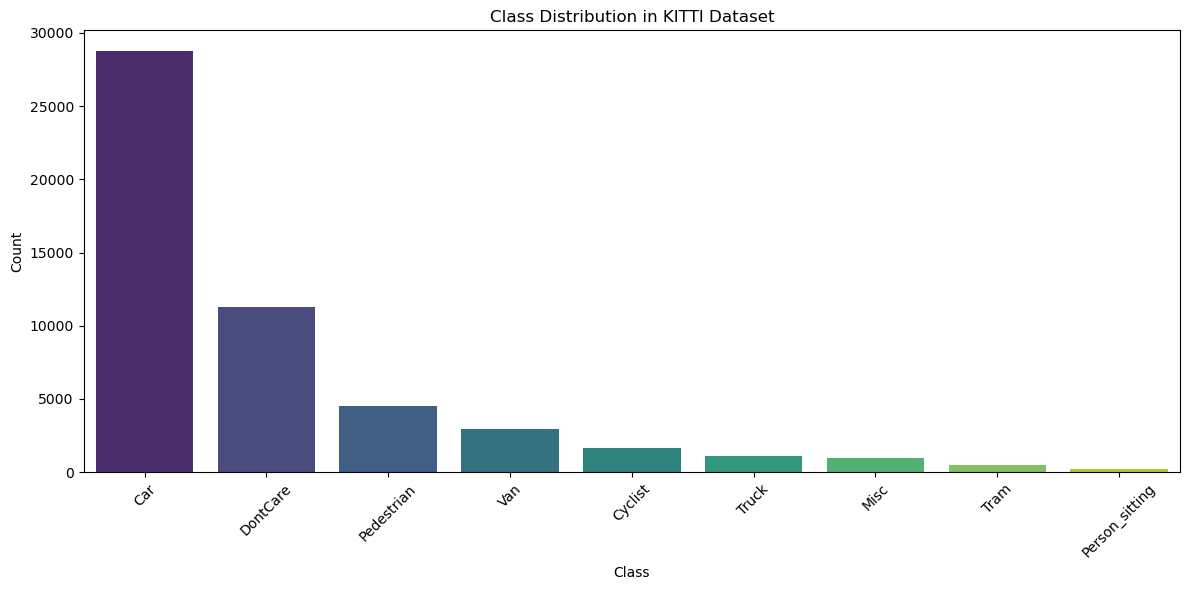

Class Imbalance Ratio: 129.47 : 1


In [8]:
# Class Distribution
class_counts = df_labels['class'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Class Distribution in KITTI Dataset")
plt.ylabel("Count")
plt.xlabel("Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

if len(class_counts) > 0:
    imbalance_ratio = class_counts.max() / class_counts.min()
    print(f"Class Imbalance Ratio: {round(imbalance_ratio, 2)} : 1")

expected_classes = ['Car', 'Pedestrian', 'Cyclist', 'Van', 'Truck', 'Person_sitting', 'Tram', 'Misc', 'DontCare']
missing_classes = [cls for cls in expected_classes if cls not in class_counts.index]
if missing_classes:
    print("Missing Classes:", missing_classes)

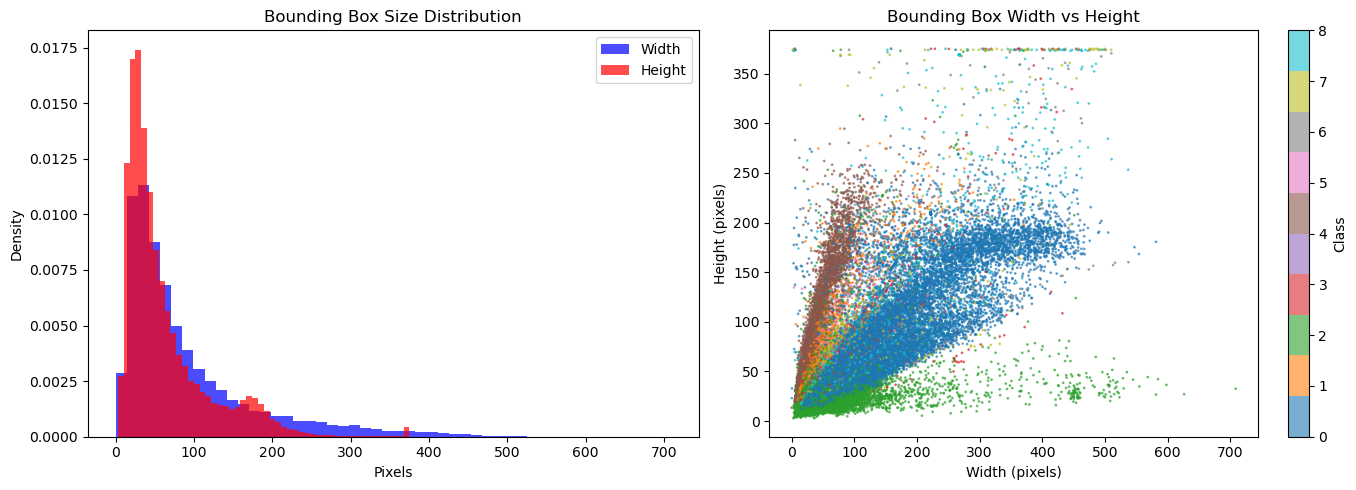

In [9]:
# Bounding Box Size Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_labels['bbox_width'], bins=50, alpha=0.7, label='Width', color='blue', density=True)
axes[0].hist(df_labels['bbox_height'], bins=50, alpha=0.7, label='Height', color='red', density=True)
axes[0].set_xlabel('Pixels')
axes[0].set_ylabel('Density')
axes[0].set_title('Bounding Box Size Distribution')
axes[0].legend()

scatter = axes[1].scatter(df_labels['bbox_width'], df_labels['bbox_height'], 
                         c=pd.Categorical(df_labels['class']).codes, cmap='tab10', alpha=0.6, s=1)
axes[1].set_xlabel('Width (pixels)')
axes[1].set_ylabel('Height (pixels)')
axes[1].set_title('Bounding Box Width vs Height')
plt.colorbar(scatter, ax=axes[1], label='Class')

plt.tight_layout()
plt.show()

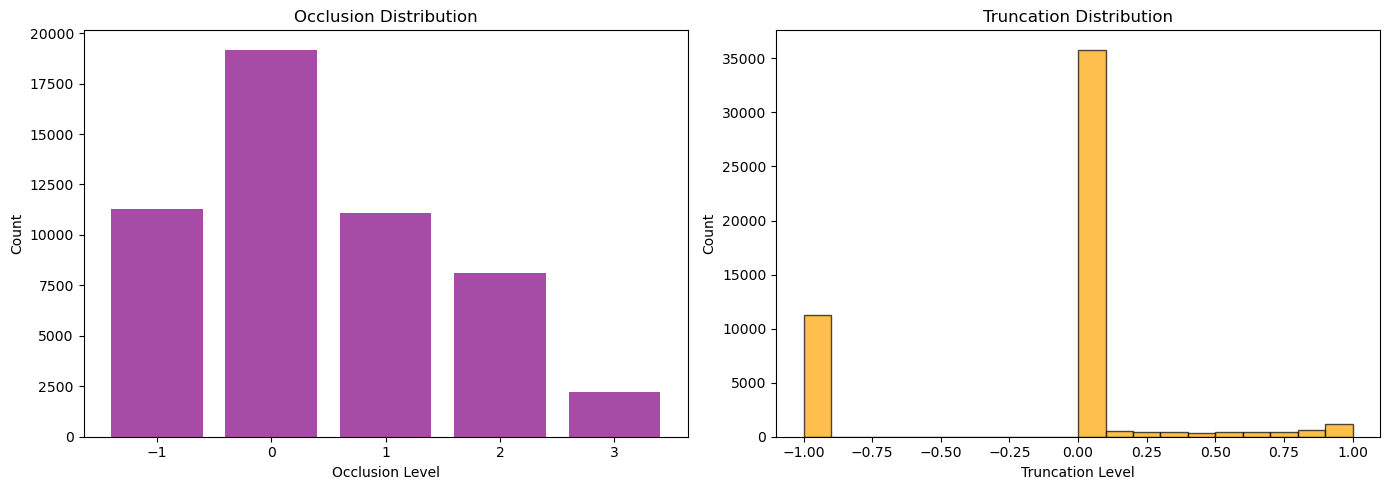

In [10]:
# Occlusion and Truncation Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

occlusion_counts = df_labels['occluded'].value_counts().sort_index()
axes[0].bar(occlusion_counts.index, occlusion_counts.values, color='purple', alpha=0.7)
axes[0].set_xlabel('Occlusion Level')
axes[0].set_ylabel('Count')
axes[0].set_title('Occlusion Distribution')

axes[1].hist(df_labels['truncated'], bins=20, color='orange', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Truncation Level')
axes[1].set_ylabel('Count')
axes[1].set_title('Truncation Distribution')

plt.tight_layout()
plt.show()

In [11]:
# Class-wise Statistics
class_size_stats = df_labels.groupby('class')[['bbox_width', 'bbox_height', 'bbox_area']].mean().round(2)
print("\n=== Average Bounding Box Sizes by Class ===")
print(class_size_stats)

class_occlusion_stats = df_labels.groupby('class')['occluded'].mean().round(2)
print("\n=== Average Occlusion by Class ===")
print(class_occlusion_stats)


=== Average Bounding Box Sizes by Class ===
                bbox_width  bbox_height  bbox_area
class                                             
Car                 111.95        66.12   11282.68
Cyclist              55.85        76.89    6675.83
DontCare             53.37        25.65    1882.53
Misc                 90.72        74.46   10898.63
Pedestrian           43.82       103.72    6220.23
Person_sitting       83.64       102.28    9724.05
Tram                153.41       104.22   25043.73
Truck                99.72        86.41   15137.24
Van                 109.65        83.60   15564.20

=== Average Occlusion by Class ===
class
Car               0.81
Cyclist           0.78
DontCare         -1.00
Misc              0.91
Pedestrian        0.58
Person_sitting    1.32
Tram              1.02
Truck             0.96
Van               1.36
Name: occluded, dtype: float64


In [12]:
# General Statistics
print("\n=== General Statistics ===")
print(f"Total Images: {len(image_files)}")
print(f"Total Annotations: {len(df_labels)}")
print(f"Average objects per image: {len(df_labels)/len(image_files):.2f}")
print(f"Max objects in a single image: {df_labels.groupby('image_name').size().max()}")
print(f"Min objects in a single image: {df_labels.groupby('image_name').size().min()}")


=== General Statistics ===
Total Images: 7481
Total Annotations: 51865
Average objects per image: 6.93
Max objects in a single image: 24
Min objects in a single image: 1


In [13]:
# Save CSV report
report_csv = "kitti_analysis_report.csv"
df_labels.to_csv(report_csv, index=False)
print(f"CSV report saved to {report_csv}")


CSV report saved to kitti_analysis_report.csv


In [14]:
# Save PDF report
report_pdf = "kitti_analysis_report.pdf"
with PdfPages(report_pdf) as pdf:
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
    plt.title("Class Distribution in KITTI Dataset")
    plt.ylabel("Count")
    plt.xlabel("Class")
    plt.xticks(rotation=45)
    plt.tight_layout()
    pdf.savefig()
    plt.close()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(df_labels['bbox_width'], bins=50, alpha=0.7, label='Width', color='blue', density=True)
    axes[0].hist(df_labels['bbox_height'], bins=50, alpha=0.7, label='Height', color='red', density=True)
    axes[0].set_xlabel('Pixels')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Bounding Box Size Distribution')
    axes[0].legend()
    
    scatter = axes[1].scatter(df_labels['bbox_width'], df_labels['bbox_height'], 
                             c=pd.Categorical(df_labels['class']).codes, cmap='tab10', alpha=0.6, s=1)
    axes[1].set_xlabel('Width (pixels)')
    axes[1].set_ylabel('Height (pixels)')
    axes[1].set_title('Bounding Box Width vs Height')
    plt.colorbar(scatter, ax=axes[1], label='Class')
    plt.tight_layout()
    pdf.savefig()
    plt.close()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    occlusion_counts = df_labels['occluded'].value_counts().sort_index()
    axes[0].bar(occlusion_counts.index, occlusion_counts.values, color='purple', alpha=0.7)
    axes[0].set_xlabel('Occlusion Level')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Occlusion Distribution')
    
    axes[1].hist(df_labels['truncated'], bins=20, color='orange', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Truncation Level')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Truncation Distribution')
    plt.tight_layout()
    pdf.savefig()
    plt.close()

print(f"PDF report saved to {report_pdf}")

C:\Users\user\AppData\Local\Temp\ipykernel_19772\1006139760.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


PDF report saved to kitti_analysis_report.pdf


In [15]:
print("✅ Analysis complete!")
print(f"Files generated:")
print(f"  - {report_csv}")
print(f"  - {report_pdf}")

✅ Analysis complete!
Files generated:
  - kitti_analysis_report.csv
  - kitti_analysis_report.pdf
